In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
# AT=> Temperature, V=> Volume, AP=> Pressure, RH=> Humidity
# PE=> Produced Energy / Output

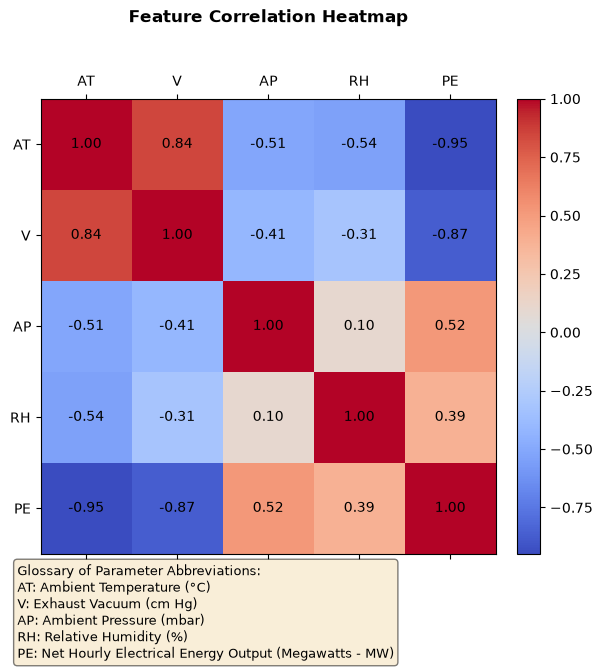

In [5]:
# Feature Correlation Heatmap
import matplotlib.pyplot as plt

corr = df.corr()
fig, ax = plt.subplots(figsize=(7, 6.5))
cax = ax.matshow(corr, cmap='coolwarm')
fig.colorbar(cax, fraction=0.046, pad=0.04)
ticks = range(len(df.columns))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(df.columns)
ax.set_yticklabels(df.columns)

# Adding correlation coefficients as text annotations
for i in range(len(df.columns)):
    for j in range(len(df.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', color='black')

plt.title('Feature Correlation Heatmap', y=1.15, fontsize=12, fontweight='bold')

# Glossary / Abbreviations Legend Box
legend_text = "Glossary of Parameter Abbreviations:\nAT: Ambient Temperature (°C)\nV: Exhaust Vacuum (cm Hg)\nAP: Ambient Pressure (mbar)\nRH: Relative Humidity (%)\nPE: Net Hourly Electrical Energy Output (Megawatts - MW)"
plt.figtext(0.15, 0.02, legend_text, fontsize=9, bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
plt.subplots_adjust(bottom=0.18)
plt.show()

In [6]:
df.isnull().sum() #No Null Values Present

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [7]:
X=df.drop("PE",axis=1)
y=df["PE"]

In [8]:
X.head()
# y.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [9]:
# Split the data out

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [10]:
df.shape

(9568, 5)

In [11]:
# Scaling the data

from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [12]:
X_train_scaled
# X_test_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]],
      shape=(7654, 4))

In [13]:
type(y_train)

pandas.Series

In [14]:
# Creating Tensors/ Converting our data into Tensors

import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

X_train_tensor=torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_tensor=torch.tensor(y_train.values, dtype=torch.float32).view(-1,1).to(device)

X_test_tensor=torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_tensor=torch.tensor(y_test.values, dtype=torch.float32).view(-1,1).to(device)

Using device: cpu


In [15]:
X_train_tensor
# X_test_tensor

tensor([[ 0.7481,  0.7201, -0.3266, -0.4971],
        [ 0.8618,  1.2652, -0.9852,  0.8182],
        [ 0.9341,  1.5231,  0.3252,  0.8017],
        ...,
        [-0.2210, -0.8350,  0.3676, -0.8355],
        [ 0.9475,  1.1425, -0.4197, -0.4546],
        [-1.7736, -1.1905,  1.9252,  0.9184]])

In [16]:
type(X_test_scaled)

numpy.ndarray

In [17]:
type(y_train)
y_train.shape

(7654,)

In [18]:
y_train_tensor
y_train_tensor.shape
# y_test_tensor
# y_test_tensor.shape

torch.Size([7654, 1])

In [19]:
# Creat Batches with the help of TensorDataset and tensor Dataloader for training

from torch.utils.data import TensorDataset, DataLoader

train_dataset=TensorDataset(X_train_tensor,y_train_tensor)
test_dataset=TensorDataset(X_test_tensor,y_test_tensor)

In [20]:
train_loader=DataLoader(train_dataset, batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset, batch_size=32)

In [21]:
print(train_loader)

### Deep Learning

In [22]:
# Defining Our ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model=nn.Sequential(
            #1st Hidden Layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

            #2nd Hidden Layer
            nn.Linear(6,6),
            nn.ReLU(),

            #Output Layer
            nn.Linear(6,1)
        )

    def forward(self,x):
        return self.model(x)

In [23]:
import torch.optim as optim

# Building Our ANN Model

model=ANN().to(device)

# loss, Optimizer
criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters())

In [24]:
# Training Our ANN Model

training_losses=[]
validation_losses=[]

best_validation_loss=float("inf")

epochs=100

for epoch in range(epochs):
    model.train()
    running_loss=0.0 #Total Training Loss 1 Epoch
    
    for xb,yb in train_loader:
        #xb= Features of 1 batch, yb= Outputs/Labels of 1 batch

        optimizer.zero_grad()
        
        outputs=model(xb) #Forward Propagation...Predicted Outputs for this Batch
        loss=criterion(outputs, yb)  #Computing the loss
        loss.backward()  #Backward Propagation
        optimizer.step() #Updating the Parameters

        running_loss+=loss.item()  #Loss is a tensor value that is converted into a python float value

    epoch_train_loss=running_loss/len(train_loader)
    training_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    running_validation_loss=0.0

    with torch.no_grad(): # Indicating to not calculate any gradient since it is done automatically using
        for xb,yb in test_loader: #Autograd

            outputs=model(xb) 
            loss=criterion(outputs, yb)

            running_validation_loss+=loss.item() 

        epoch_validation_loss=running_validation_loss/len(test_loader)
        validation_losses.append(epoch_validation_loss)

        print(f"Epoch {epoch+1}/{epochs} ==> Training Loss = {epoch_train_loss} & Validation Loss = {epoch_validation_loss}")

        if epoch_validation_loss<best_validation_loss:
            best_validation_loss=epoch_validation_loss
            torch.save(model.state_dict(), "best_model.pt") # .pt or .pth

Epoch 1/100 ==> Training Loss = 206227.36614583334 & Validation Loss = 203728.56067708333
Epoch 2/100 ==> Training Loss = 194531.6673828125 & Validation Loss = 179332.65182291667


Epoch 3/100 ==> Training Loss = 150449.7163736979 & Validation Loss = 116368.34192708334
Epoch 4/100 ==> Training Loss = 82142.16282552083 & Validation Loss = 52831.663411458336


Epoch 5/100 ==> Training Loss = 37005.964095052084 & Validation Loss = 26967.895377604167
Epoch 6/100 ==> Training Loss = 23455.261791992187 & Validation Loss = 20727.751106770833


Epoch 7/100 ==> Training Loss = 19044.723474121092 & Validation Loss = 16970.569986979168
Epoch 8/100 ==> Training Loss = 15448.997322591145 & Validation Loss = 13447.62763671875


Epoch 9/100 ==> Training Loss = 11968.142171223959 & Validation Loss = 10032.75057779948
Epoch 10/100 ==> Training Loss = 8663.86840209961 & Validation Loss = 6974.052799479166


...

Epoch 91/100 ==> Training Loss = 20.57586347659429 & Validation Loss = 19.205248721440633
Epoch 92/100 ==> Training Loss = 20.50398860772451 & Validation Loss = 18.677692445119224


Epoch 93/100 ==> Training Loss = 20.479517837365467 & Validation Loss = 20.6705011844635
Epoch 94/100 ==> Training Loss = 20.596536393960317 & Validation Loss = 18.66492748260498


Epoch 95/100 ==> Training Loss = 20.504891137282055 & Validation Loss = 19.71357266108195
Epoch 96/100 ==> Training Loss = 20.447559690475465 & Validation Loss = 19.27590602238973


Epoch 97/100 ==> Training Loss = 20.499934534231823 & Validation Loss = 18.585234308242796
Epoch 98/100 ==> Training Loss = 20.64373509287834 & Validation Loss = 18.973849773406982


Epoch 99/100 ==> Training Loss = 20.5480739235878 & Validation Loss = 18.554912741978963
Epoch 100/100 ==> Training Loss = 20.494358881314596 & Validation Loss = 19.185944048563638


In [25]:
import matplotlib.pyplot as plt

loss_df=pd.DataFrame({
    "Training Loss": training_losses,
    "Validation Loss":validation_losses
})

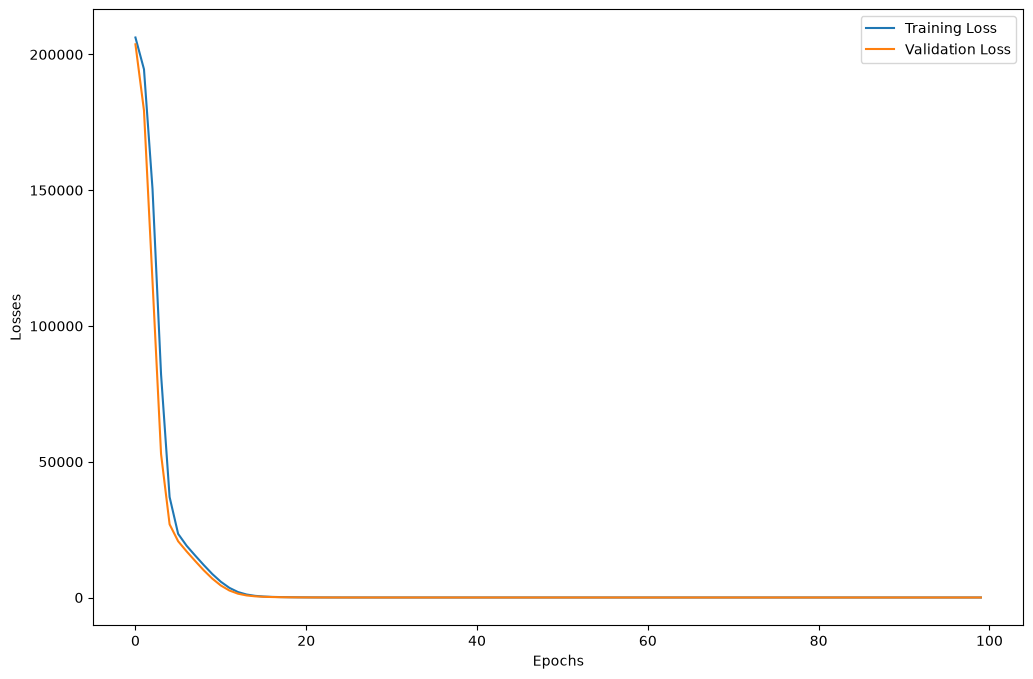

In [26]:
#Plotting The Losses

plt.figure(figsize=(12,8))

plt.plot(loss_df["Training Loss"], label="Training Loss")
plt.plot(loss_df["Validation Loss"], label="Validation Loss")



plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()
plt.savefig("loss_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
# Retrieving the best parameters or Loading the best model

model.load_state_dict(torch.load("best_model.pt", map_location=device))

<All keys matched successfully>

In [28]:
# Evaluate or Testing our Model

model.eval()

with torch.no_grad():
    train_preds=model(X_train_tensor)
    test_preds=model(X_test_tensor)

    train_mse_loss=criterion(train_preds, y_train_tensor)
    test_mse_loss=criterion(test_preds, y_test_tensor)

train_mse = train_mse_loss.item()
test_mse = test_mse_loss.item()

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

from sklearn.metrics import mean_absolute_error, r2_score

train_mae = mean_absolute_error(y_train, train_preds.cpu().numpy())
test_mae = mean_absolute_error(y_test, test_preds.cpu().numpy())

train_r2 = r2_score(y_train, train_preds.cpu().numpy())
test_r2 = r2_score(y_test, test_preds.cpu().numpy())

print(f"Training MSE: {train_mse:.4f}")
print(f"Testing MSE: {test_mse:.4f}")
print(f"Training RMSE: {train_rmse:.4f} MW")
print(f"Testing RMSE: {test_rmse:.4f} MW")
print(f"Training MAE: {train_mae:.4f} MW")
print(f"Testing MAE: {test_mae:.4f} MW")
print(f"Training R2 Score: {train_r2 * 100:.2f}%")
print(f"Testing R2 Score: {test_r2 * 100:.2f}%")

Training MSE: 20.2036
Testing MSE: 18.5415
Training RMSE: 4.4948 MW
Testing RMSE: 4.3060 MW
Training MAE: 3.5350 MW
Testing MAE: 3.4178 MW
Training R2 Score: 93.09%
Testing R2 Score: 93.52%


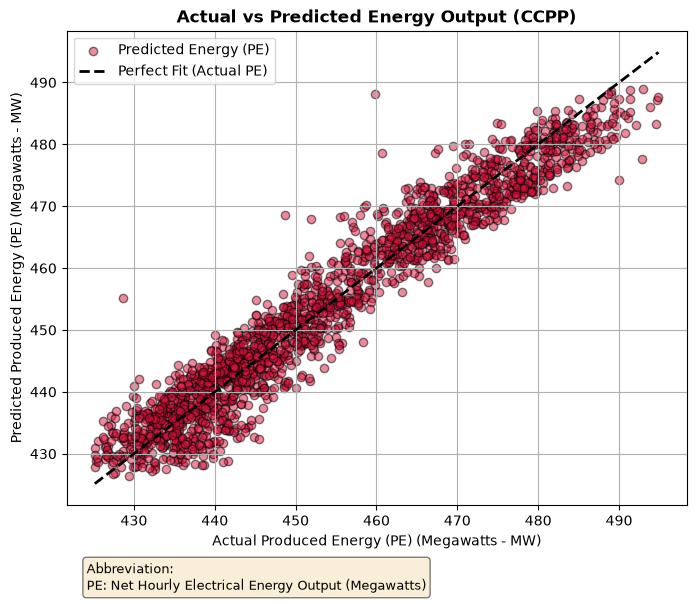

In [29]:
# Plotting Actual vs Predicted Values (LinkedIn Visual Recommendation #1)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6.5))
plt.scatter(y_test, test_preds.cpu().numpy(), alpha=0.5, color='crimson', edgecolors='k', label='Predicted Energy (PE)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Fit (Actual PE)')
plt.xlabel('Actual Produced Energy (PE) (Megawatts - MW)')
plt.ylabel('Predicted Produced Energy (PE) (Megawatts - MW)')
plt.title('Actual vs Predicted Energy Output (CCPP)', fontsize=12, fontweight='bold')

# Legend and Glossary
plt.legend(loc='upper left')
legend_text = "Abbreviation:\nPE: Net Hourly Electrical Energy Output (Megawatts)"
plt.figtext(0.15, 0.02, legend_text, fontsize=9, bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
plt.subplots_adjust(bottom=0.15)
plt.grid(True)
plt.savefig("actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
predicted_df=pd.DataFrame(test_preds.cpu().numpy(), columns=["Predicted Value"])
actual_df=pd.DataFrame(y_test.values, columns=["Actual Value"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Value,Actual Value
0,435.004639,433.27
1,436.669708,438.16
2,461.124481,458.42
3,476.248718,480.82
4,434.841675,441.41
...,...,...
1909,451.318939,456.70
1910,431.339478,438.04
1911,467.579193,467.80
1912,430.734894,437.14
